In [ ]:
Face Generator with GAN Kaggle https://www.kaggle.com/code/ashishjangra27/face-generation-with-gan

Github for Pretrained Models https://github.com/AshishJangra27/Face-Generator-with-GAN

In [13]:
import os
import time
from tqdm import tqdm
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

IMAGE_SHAPE = (128, 128, 3)
NOISE_DIM = 100
BATCH_SIZE = 128
EPOCHS = 50
DATA_PATH = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/'

def preprocess_image(file_path):
    img_raw = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, (IMAGE_SHAPE[0], IMAGE_SHAPE[1]))
    img = (img / 127.5) - 1.0  # Normalize to [-1, 1]
    return img

def load_celeba_images(path):
    all_files = [os.path.join(path, f) for f in os.listdir(path)[:10000] if f.endswith('.jpg')]
    dataset = tf.data.Dataset.from_tensor_slices(all_files)
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    images_list = []
    for batch in tqdm(dataset.batch(1024).prefetch(tf.data.AUTOTUNE)):
        images_list.append(batch)

    return tf.concat(images_list, axis=0)

images = load_celeba_images(DATA_PATH)
dataset = tf.data.Dataset.from_tensor_slices(images) \
                         .shuffle(buffer_size=50000) \
                         .batch(BATCH_SIZE) \
                         .prefetch(tf.data.AUTOTUNE)

100%|██████████| 10/10 [00:05<00:00,  1.84it/s]


In [14]:
import tensorflow as tf
from tensorflow.keras import layers

def build_generator(NOISE_DIM=NOISE_DIM):
    model = tf.keras.Sequential([
        # 1) Start with a dense layer that reshapes to 8x8 with 512 channels
        layers.Dense(8*8*512, use_bias=False, input_shape=(NOISE_DIM,)),
        layers.Reshape((8, 8, 512)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 2) Upsample to 16x16
        layers.Conv2DTranspose(256, (4,4), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 3) Upsample to 32x32
        layers.Conv2DTranspose(128, (4,4), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 4) Upsample to 64x64
        layers.Conv2DTranspose(64, (4,4), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 5) Upsample to 128x128
        layers.Conv2DTranspose(32, (4,4), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 6) Final layer → 128x128x3, use tanh for output in [-1,1]
        layers.Conv2DTranspose(3, (4,4), strides=(1,1), padding='same', use_bias=False, activation='tanh')
    ], name="Generator")

    return model


def build_discriminator():
    model = tf.keras.Sequential([
        # 1) Downsample from 128x128 to 64x64
        layers.Conv2D(64, (4,4), strides=(2,2), padding='same', 
                      input_shape=(128,128,3)),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        # 2) Downsample to 32x32
        layers.Conv2D(128, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        # 3) Downsample to 16x16
        layers.Conv2D(256, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        # 4) Downsample to 8x8
        layers.Conv2D(512, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        # 5) Flatten to a single logit
        layers.Flatten(),
        layers.Dense(1)
    ], name="Discriminator")

    return model

In [15]:
!git clone https://github.com/AshishJangra27/Face-Generator-with-GAN

fatal: destination path 'Face-Generator-with-GAN' already exists and is not an empty directory.


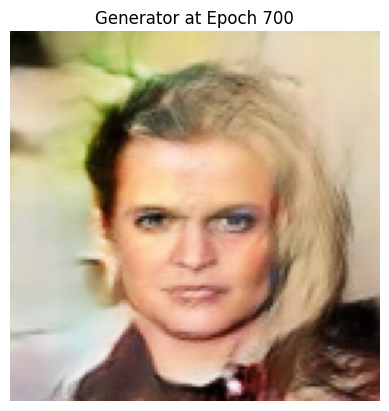

In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the model trained for 700 epochs
model_path = 'Face-Generator-with-GAN/generator_700.h5'
generator = tf.keras.models.load_model(model_path, compile=False)

# Generate a face
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, :] * 0.5 + 0.5)
plt.axis('off')
plt.title("Generator at Epoch 700")
plt.show()

In [17]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

discriminator = build_discriminator()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

100%|██████████| 79/79 [01:00<00:00,  1.30it/s]


Time for epoch 1 is 60.88302445411682 sec


100%|██████████| 79/79 [00:56<00:00,  1.40it/s]


Time for epoch 2 is 56.629788875579834 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 3 is 57.17958879470825 sec


100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 4 is 56.90564584732056 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 5 is 57.137213945388794 sec


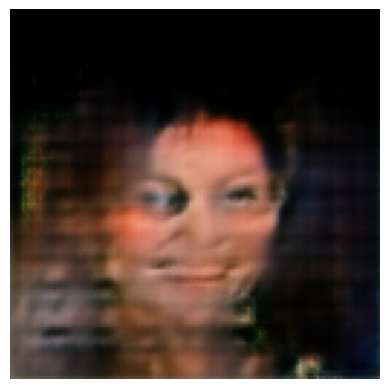

100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 6 is 56.96879553794861 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 7 is 57.347482442855835 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 8 is 57.2086718082428 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 9 is 57.11233735084534 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 10 is 57.12333154678345 sec


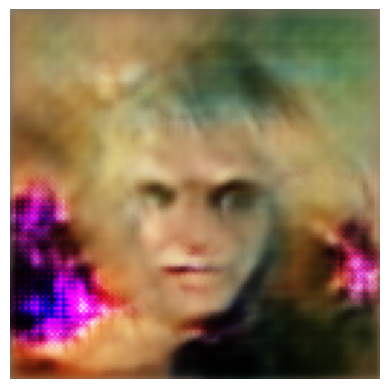

100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 11 is 56.79430794715881 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 12 is 57.19017291069031 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 13 is 57.31578230857849 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 14 is 57.26739549636841 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 15 is 57.26789951324463 sec


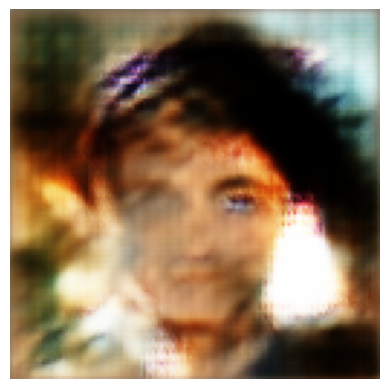

100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 16 is 56.79525017738342 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 17 is 57.06007790565491 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 18 is 57.12317085266113 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 19 is 57.13358664512634 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 20 is 57.13302540779114 sec


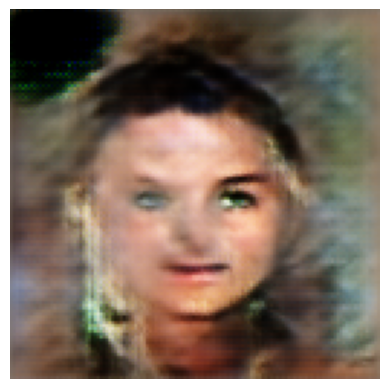

100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 21 is 56.89775252342224 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 22 is 57.380629539489746 sec


100%|██████████| 79/79 [00:57<00:00,  1.39it/s]


Time for epoch 23 is 57.01724028587341 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 24 is 57.09396457672119 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 25 is 57.12840557098389 sec


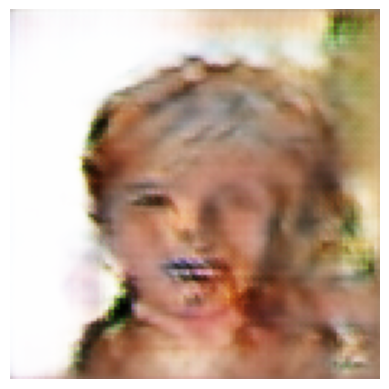

100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 26 is 56.777058362960815 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 27 is 57.16331481933594 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 28 is 57.2583429813385 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 29 is 57.22320818901062 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 30 is 57.3240704536438 sec


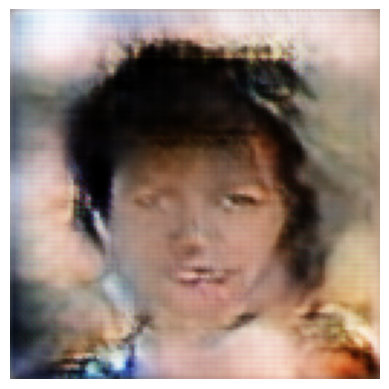

100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 31 is 56.96550369262695 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 32 is 57.32499575614929 sec


100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 33 is 56.92336344718933 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 34 is 57.06766176223755 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 35 is 57.246777296066284 sec


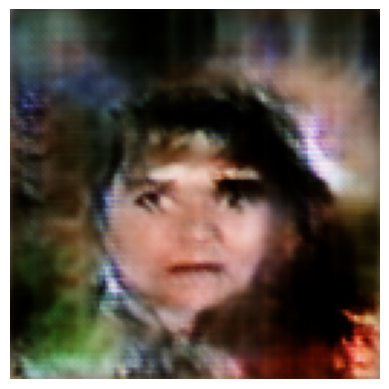

100%|██████████| 79/79 [00:57<00:00,  1.39it/s]


Time for epoch 36 is 57.015528440475464 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 37 is 57.36492347717285 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 38 is 57.263874769210815 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 39 is 57.14307141304016 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 40 is 57.15428447723389 sec


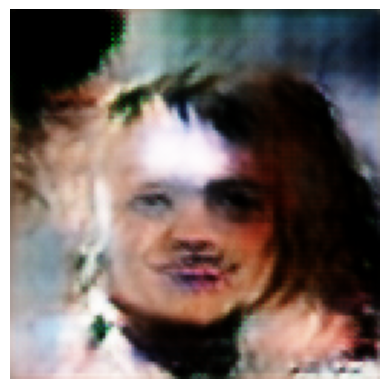

100%|██████████| 79/79 [00:56<00:00,  1.40it/s]


Time for epoch 41 is 56.61271071434021 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 42 is 57.14699459075928 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 43 is 57.079848289489746 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 44 is 57.23341202735901 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 45 is 57.40365386009216 sec


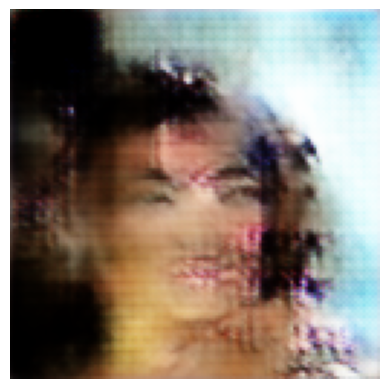

100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 46 is 56.96881699562073 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 47 is 57.20752000808716 sec


100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 48 is 56.97456169128418 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 49 is 57.27671217918396 sec


100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 50 is 57.28141736984253 sec


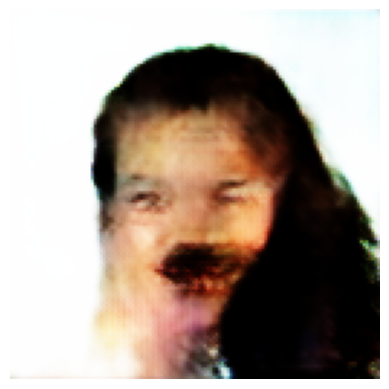

In [19]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in tqdm(dataset):
            train_step(image_batch)

        print(f'Time for epoch {epoch + 1} is {time.time()-start} sec')

        if (epoch + 1) % 5 == 0:
            noise = tf.random.normal([1, NOISE_DIM])
            img = generator(noise, training=False)
            plt.imshow(img[0, :, :, :] * 0.5 + 0.5)
            plt.axis('off')
            plt.show()

train(dataset, EPOCHS)

Epoch 701: 100%|██████████| 79/79 [00:57<00:00,  1.36it/s]


Time for epoch 701 is 57.93 sec


Epoch 702: 100%|██████████| 79/79 [00:56<00:00,  1.40it/s]


Time for epoch 702 is 56.40 sec


Epoch 703: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


...

Epoch 708: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 708 is 57.17 sec


Epoch 709: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 709 is 57.34 sec


Epoch 710: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


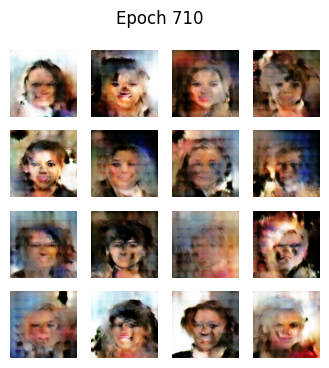

Time for epoch 710 is 58.47 sec


Epoch 711: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 711 is 56.88 sec


Epoch 712: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 712 is 57.08 sec


...

Epoch 718: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 718 is 57.37 sec


Epoch 719: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 719 is 57.37 sec


Epoch 720: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


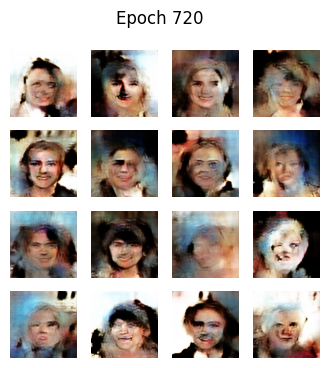

Time for epoch 720 is 58.25 sec


Epoch 721: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 721 is 56.95 sec


Epoch 722: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 722 is 57.37 sec


...

Epoch 728: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 728 is 57.35 sec


Epoch 729: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 729 is 57.40 sec


Epoch 730: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


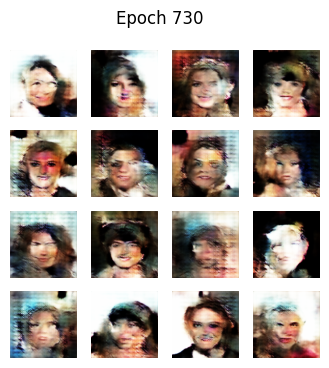

Time for epoch 730 is 58.25 sec


Epoch 731: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 731 is 56.98 sec


Epoch 732: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 732 is 57.42 sec


...

Epoch 738: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 738 is 57.38 sec


Epoch 739: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 739 is 57.37 sec


Epoch 740: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


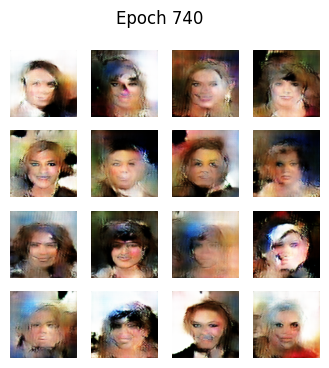

Time for epoch 740 is 58.15 sec


Epoch 741: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 741 is 56.68 sec


Epoch 742: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 742 is 56.99 sec


...

Epoch 748: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 748 is 57.39 sec


Epoch 749: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 749 is 57.40 sec


Epoch 750: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


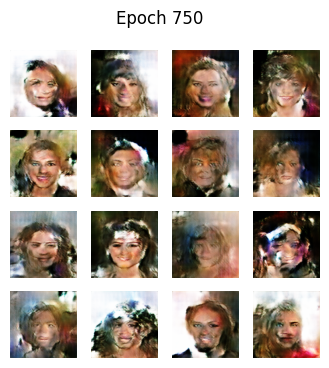

Time for epoch 750 is 58.54 sec


Epoch 751: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 751 is 56.93 sec


Epoch 752: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 752 is 57.36 sec


...

Epoch 758: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 758 is 57.32 sec


Epoch 759: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 759 is 57.34 sec


Epoch 760: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


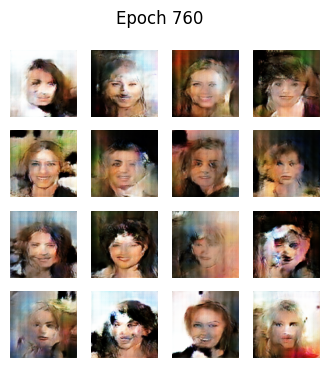

Time for epoch 760 is 58.22 sec


Epoch 761: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 761 is 56.93 sec


Epoch 762: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 762 is 57.33 sec


...

Epoch 768: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 768 is 57.41 sec


Epoch 769: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 769 is 57.38 sec


Epoch 770: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


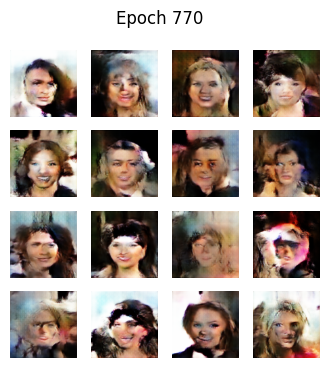

Time for epoch 770 is 57.92 sec


Epoch 771: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 771 is 56.89 sec


Epoch 772: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 772 is 57.41 sec


...

Epoch 778: 100%|██████████| 79/79 [00:57<00:00,  1.39it/s]


Time for epoch 778 is 57.02 sec


Epoch 779: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 779 is 57.31 sec


Epoch 780: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


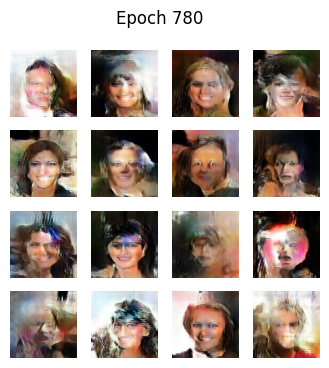

Time for epoch 780 is 58.26 sec


Epoch 781: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 781 is 56.94 sec


Epoch 782: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 782 is 57.40 sec


...

Epoch 788: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 788 is 57.19 sec


Epoch 789: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 789 is 57.40 sec


Epoch 790: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


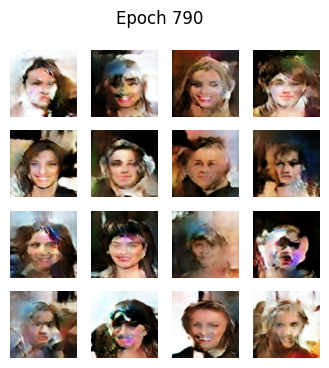

Time for epoch 790 is 58.23 sec


Epoch 791: 100%|██████████| 79/79 [00:56<00:00,  1.39it/s]


Time for epoch 791 is 56.70 sec


Epoch 792: 100%|██████████| 79/79 [00:57<00:00,  1.39it/s]


Time for epoch 792 is 57.03 sec


...

Epoch 798: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 798 is 57.38 sec


Epoch 799: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


Time for epoch 799 is 57.40 sec


Epoch 800: 100%|██████████| 79/79 [00:57<00:00,  1.38it/s]


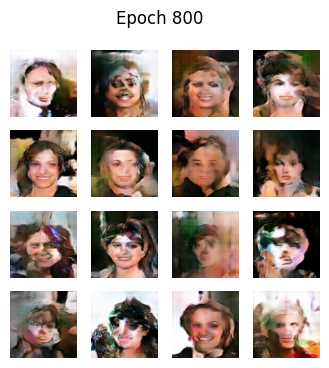

Time for epoch 800 is 58.25 sec


In [20]:
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_and_compare(dataset, start_epoch, end_epoch):
    # Fixed seed to track the exact same faces evolving over time
    seed = tf.random.normal([16, NOISE_DIM])
    
    for epoch in range(start_epoch, end_epoch + 1):
        start = time.time()
        
        # Training Step
        for image_batch in tqdm(dataset, desc=f"Epoch {epoch}"):
            train_step(image_batch)
            
        # Every 10 epochs: Compare (Visualize only)
        if epoch % 10 == 0:
            predictions = generator(seed, training=False)
            
            fig = plt.figure(figsize=(4, 4))

            for i in range(predictions.shape[0]):
                plt.subplot(4, 4, i+1)
                plt.imshow(predictions[i, :, :, :] * 0.5 + 0.5)
                plt.axis('off')
            
            plt.suptitle(f"Epoch {epoch}")
            plt.show()
            
        print(f'Time for epoch {epoch} is {time.time()-start:.2f} sec')

# Run the training from 701 to 800
train_and_compare(dataset, start_epoch=701, end_epoch=800)

In [21]:
generator.save("generator_800.h5")
print("Saved final model: generator_800.h5")

Saved final model: generator_800.h5


In [22]:
from IPython.display import FileLink

# This creates a clickable link to download the file
FileLink(r'generator_800.h5')

/kaggle/working/generator_800.h5